<a href="https://colab.research.google.com/github/MattKim98/aipython/blob/main/260529.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [31]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [16]:
df = pd.read_csv('/content/Iris.csv')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             150 non-null    int64  
 1   SepalLengthCm  150 non-null    float64
 2   SepalWidthCm   150 non-null    float64
 3   PetalLengthCm  150 non-null    float64
 4   PetalWidthCm   150 non-null    float64
 5   Species        150 non-null    object 
dtypes: float64(4), int64(1), object(1)
memory usage: 7.2+ KB


In [15]:
print(df.shape[0])
print(df.shape[1])

150
6


In [5]:
print(df.columns)

Index(['Id', 'SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm',
       'Species'],
      dtype='object')


In [18]:
print(df.isnull().sum())

Id               0
SepalLengthCm    0
SepalWidthCm     0
PetalLengthCm    0
PetalWidthCm     0
Species          0
dtype: int64


In [19]:
print(f"꽃받침 길이(SepalLengthCm)의 평균: {df['SepalLengthCm'].mean():.2f}")
print(f"꽃잎 너비(PetalWidthCm)의 최댓값: {df['PetalWidthCm'].max():.2f}")

꽃받침 길이(SepalLengthCm)의 평균: 5.84
꽃잎 너비(PetalWidthCm)의 최댓값: 2.50


In [21]:
species_counts = df['Species'].value_counts()
print("붓꽃 종류별 개수:\n", species_counts)
print(f"세 종류의 개수가 같나요?: {species_counts.nunique() == 1}")

붓꽃 종류별 개수:
 Species
Iris-setosa        50
Iris-versicolor    50
Iris-virginica     50
Name: count, dtype: int64
세 종류의 개수가 같나요?: True


In [22]:
petal_length_gt_2_count = df[df['PetalLengthCm'] > 2.0].shape[0]
print(f"꽃잎 길이(PetalLengthCm)가 2.0보다 큰 데이터의 개수: {petal_length_gt_2_count}개")

sepal_width_gt_3_5 = df[df['SepalWidthCm'] > 3.5]
print("\n꽃받침 너비(SepalWidthCm)가 3.5보다 큰 데이터:\n")
display(sepal_width_gt_3_5.head())

꽃잎 길이(PetalLengthCm)가 2.0보다 큰 데이터의 개수: 100개

꽃받침 너비(SepalWidthCm)가 3.5보다 큰 데이터:



,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
4,5,5.0,3.6,1.4,0.2,Iris-setosa
5,6,5.4,3.9,1.7,0.4,Iris-setosa
10,11,5.4,3.7,1.5,0.2,Iris-setosa
14,15,5.8,4.0,1.2,0.2,Iris-setosa
15,16,5.7,4.4,1.5,0.4,Iris-setosa


In [23]:
avg_petal_length_versicolor = df[df['Species'] == 'Iris-versicolor']['PetalLengthCm'].mean()
print(f"'Iris-versicolor' 종류의 평균 꽃잎 길이: {avg_petal_length_versicolor:.2f}")

max_sepal_width_virginica = df[df['Species'] == 'Iris-virginica']['SepalWidthCm'].max()
print(f"'Iris-virginica' 종류의 최대 꽃받침 너비: {max_sepal_width_virginica:.2f}")

'Iris-versicolor' 종류의 평균 꽃잎 길이: 4.26
'Iris-virginica' 종류의 최대 꽃받침 너비: 3.80


In [27]:
species_mean = df.groupby('Species').mean()
display(species_mean)

print(f"꽃받침 길이(SepalLengthCm)가 가장 긴 종류: {species_mean['SepalLengthCm'].idxmax()} ({species_mean['SepalLengthCm'].max():.2f} cm)")
print(f"꽃잎 너비(PetalWidthCm)가 가장 넓은 종류: {species_mean['PetalWidthCm'].idxmax()} ({species_mean['PetalWidthCm'].max():.2f} cm)")

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
Species,,,,,
Iris-setosa,25.5,5.006,3.418,1.464,0.244
Iris-versicolor,75.5,5.936,2.770,4.260,1.326
Iris-virginica,125.5,6.588,2.974,5.552,2.026


꽃받침 길이(SepalLengthCm)가 가장 긴 종류: Iris-virginica (6.59 cm)
꽃잎 너비(PetalWidthCm)가 가장 넓은 종류: Iris-virginica (2.03 cm)


In [28]:
df['SepalArea'] = df['SepalLengthCm'] * df['SepalWidthCm']
df['PetalArea'] = df['PetalLengthCm'] * df['PetalWidthCm']

species_area_mean = df.groupby('Species')[['SepalArea', 'PetalArea']].mean()
display(species_area_mean)

print(f"꽃받침 면적이 가장 큰 종류: {species_area_mean['SepalArea'].idxmax()} ({species_area_mean['SepalArea'].max():.2f})")
print(f"꽃잎 면적이 가장 큰 종류: {species_area_mean['PetalArea'].idxmax()} ({species_area_mean['PetalArea'].max():.2f})")

,SepalArea,PetalArea
Species,,
Iris-setosa,17.2088,0.3628
Iris-versicolor,16.5262,5.7204
Iris-virginica,19.6846,11.2962


꽃받침 면적이 가장 큰 종류: Iris-virginica (19.68)
꽃잎 면적이 가장 큰 종류: Iris-virginica (11.30)


In [29]:
filtered_data = df[(df['SepalWidthCm'] >= 3.0) & (df['PetalWidthCm'] >= 1.5)]
print(f"조건을 만족하는 데이터 개수: {filtered_data.shape[0]}개")
print("\n조건을 만족하는 데이터의 종류 분포:\n")
print(filtered_data['Species'].value_counts())

조건을 만족하는 데이터 개수: 39개

조건을 만족하는 데이터의 종류 분포:

Species
Iris-virginica     29
Iris-versicolor    10
Name: count, dtype: int64


In [30]:
top_10_by_petal_length = df.nlargest(10, 'PetalLengthCm')
print("꽃잎 길이 기준 Top 10 데이터의 종류:\n")
species_in_top_10 = top_10_by_petal_length['Species'].value_counts()
print(species_in_top_10)

print(f"\nTop 10에 가장 많이 포함된 종류: {species_in_top_10.idxmax()} ({species_in_top_10.max()}개)")
print(f"Top 10에 가장 적게 포함된 종류 (또는 포함되지 않은 종류): {species_in_top_10.idxmin()} ({species_in_top_10.min()}개)")

꽃잎 길이 기준 Top 10 데이터의 종류:

Species
Iris-virginica    10
Name: count, dtype: int64

Top 10에 가장 많이 포함된 종류: Iris-virginica (10개)
Top 10에 가장 적게 포함된 종류 (또는 포함되지 않은 종류): Iris-virginica (10개)


/tmp/ipykernel_1896/1212494063.py:16: UserWarning: Glyph 54217 (\N{HANGUL SYLLABLE PYEONG}) missing from font(s) DejaVu Sans.
  plt.tight_layout(rect=[0, 0.03, 1, 0.96])
/tmp/ipykernel_1896/1212494063.py:16: UserWarning: Glyph 44512 (\N{HANGUL SYLLABLE GYUN}) missing from font(s) DejaVu Sans.
  plt.tight_layout(rect=[0, 0.03, 1, 0.96])
/tmp/ipykernel_1896/1212494063.py:16: UserWarning: Glyph 44867 (\N{HANGUL SYLLABLE GGOC}) missing from font(s) DejaVu Sans.
  plt.tight_layout(rect=[0, 0.03, 1, 0.96])
/tmp/ipykernel_1896/1212494063.py:16: UserWarning: Glyph 48155 (\N{HANGUL SYLLABLE BAD}) missing from font(s) DejaVu Sans.
  plt.tight_layout(rect=[0, 0.03, 1, 0.96])
/tmp/ipykernel_1896/1212494063.py:16: UserWarning: Glyph 52840 (\N{HANGUL SYLLABLE CIM}) missing from font(s) DejaVu Sans.
  plt.tight_layout(rect=[0, 0.03, 1, 0.96])
/tmp/ipykernel_1896/1212494063.py:16: UserWarning: Glyph 44600 (\N{HANGUL SYLLABLE GIL}) missing from font(s) DejaVu Sans.
  plt.tight_layout(rect=[0, 0.03, 1, 

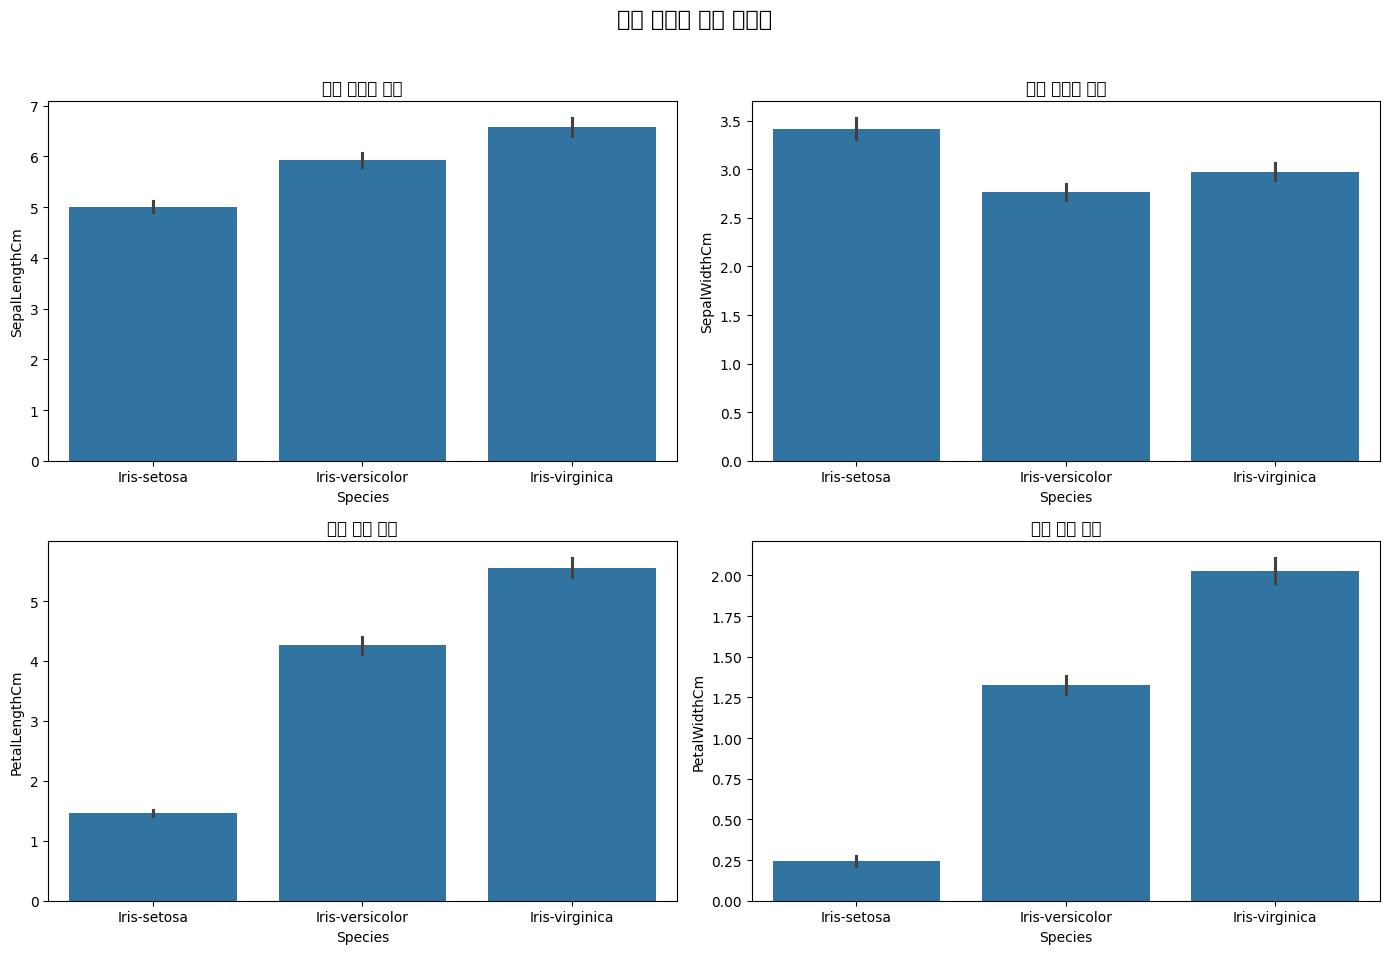


가장 큰 차이를 보이는 측정값은 'PetalLengthCm'이며, 차이는 4.09입니다.


In [34]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('붓꽃 종류별 평균 측정값', fontsize=16)

sns.barplot(x='Species', y='SepalLengthCm', data=df, ax=axes[0, 0])
axes[0, 0].set_title('평균 꽃받침 길이')

sns.barplot(x='Species', y='SepalWidthCm', data=df, ax=axes[0, 1])
axes[0, 1].set_title('평균 꽃받침 너비')

sns.barplot(x='Species', y='PetalLengthCm', data=df, ax=axes[1, 0])
axes[1, 0].set_title('평균 꽃잎 길이')

sns.barplot(x='Species', y='PetalWidthCm', data=df, ax=axes[1, 1])
axes[1, 1].set_title('평균 꽃잎 너비')

plt.tight_layout(rect=[0, 0.03, 1, 0.96])
plt.show()

# 가장 큰 차이를 보이는 측정값 찾기
species_mean = df.groupby('Species')[['SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm']].mean()
differences = species_mean.max() - species_mean.min()
most_different_measurement = differences.idxmax()
max_difference_value = differences.max()

print(f"\n가장 큰 차이를 보이는 측정값은 '{most_different_measurement}'이며, 차이는 {max_difference_value:.2f}입니다.")

In [33]:
# [코드 11-49, 11-50] 한글 폰트 설치 (Colab 환경)
!apt-get update -qq
!apt-get install fonts-nanum -qq
!fc-cache -fv

import matplotlib.font_manager as fm
font10 = fm.FontProperties(
    fname='/usr/share/fonts/truetype/nanum/NanumGothic.ttf',
    size=10
)


W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
Selecting previously unselected package fonts-nanum.
(Reading database ... 118242 files and directories currently installed.)
Preparing to unpack .../fonts-nanum_20200506-1_all.deb ...
Unpacking fonts-nanum (20200506-1) ...
Setting up fonts-nanum (20200506-1) ...
Processing triggers for fontconfig (2.13.1-4.2ubuntu5) ...
/usr/share/fonts: caching, new cache contents: 0 fonts, 1 dirs
/usr/share/fonts/truetype: caching, new cache contents: 0 fonts, 3 dirs
/usr/share/fonts/truetype/humor-sans: caching, new cache contents: 1 fonts, 0 dirs
/usr/share/fonts/truetype/liberation: caching, new cache contents: 16 fonts, 0 dirs
/usr/share/fonts/truetype/nanum: caching, new cache contents: 12 fonts, 0 dirs
/usr/local/share/fonts: caching, new cache contents: 0 fonts, 0 dirs
/root/.local/share/fonts: skipping, no